In [ ]:
!pip install split-folders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from keras.preprocessing.image import ImageDataGenerator , load_img , img_to_array
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, MaxPool2D, Dense
import matplotlib.pyplot as plt

import numpy as np
from skimage import transform
import splitfolders
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns

import splitfolders

In [ ]:
splitfolders.ratio(
    "/content/drive/MyDrive/Research/kidney/Kidney dataset major project",
   output="/content/drive/MyDrive/Research/kidney/Kidney dataset major project/dataset",
   seed=7,
   ratio=(0.90,0.050, 0.050)
)

In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255)
valid_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

train_dataset = train_datagen.flow_from_directory('/content/drive/MyDrive/Research/kidney/Kidney dataset major project/dataset/train',
                                                  target_size=(200, 200),
                                                  color_mode='grayscale', 
                                                  class_mode='categorical', 
                                                  batch_size=100,
                                                  )

test_dataset = test_datagen.flow_from_directory('/content/drive/MyDrive/Research/kidney/Kidney dataset major project/dataset/test',
                                                target_size=(200, 200),
                                                class_mode='categorical',
                                                color_mode='grayscale',
                                                batch_size=100,
                                                shuffle=False
                                                )

valid_dataset = valid_datagen.flow_from_directory('/content/drive/MyDrive/Research/kidney/Kidney dataset major project/dataset/val',
                                                  target_size=(200, 200),
                                                  class_mode='categorical',
                                                  batch_size=100,
                                                  color_mode='grayscale',
                                                  )


Found 11215 images belonging to 5 classes.
Found 627 images belonging to 5 classes.
Found 621 images belonging to 5 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=train_dataset.image_shape))
model.add(MaxPool2D(2))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(2))


model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2))


model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2))


model.add(Flatten())

model.add(Dense(512, activation='relu'))


model.add(Dense(5, activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 97, 97, 32)        9248      
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 48, 48, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 46, 46, 64)        18496     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 23, 23, 64)      

In [ ]:
import keras
METRICS = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
    
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=METRICS)

In [ ]:
Info = model.fit(
                 train_dataset,
                 validation_data=valid_dataset,
                 epochs=25,
                 )

Epoch 1/25
113/113 [==============================] - 87s 773ms/step - loss: 0.0475 - accuracy: 0.9871 - precision: 0.9876 - recall: 0.9867 - val_loss: 0.0099 - val_accuracy: 0.9984 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 2/25
113/113 [==============================] - 86s 760ms/step - loss: 0.0802 - accuracy: 0.9889 - precision: 0.9894 - recall: 0.9888 - val_loss: 0.0153 - val_accuracy: 0.9968 - val_precision: 0.9968 - val_recall: 0.9968
Epoch 3/25
113/113 [==============================] - 86s 759ms/step - loss: 0.0633 - accuracy: 0.9873 - precision: 0.9874 - recall: 0.9871 - val_loss: 0.0103 - val_accuracy: 0.9984 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 4/25
113/113 [==============================] - 86s 759ms/step - loss: 0.0367 - accuracy: 0.9922 - precision: 0.9927 - recall: 0.9922 - val_loss: 0.0168 - val_accuracy: 0.9968 - val_precision: 0.9968 - val_recall: 0.9968
Epoch 5/25
113/113 [==============================] - 86s 763ms/step - loss: 0.0685 - accura

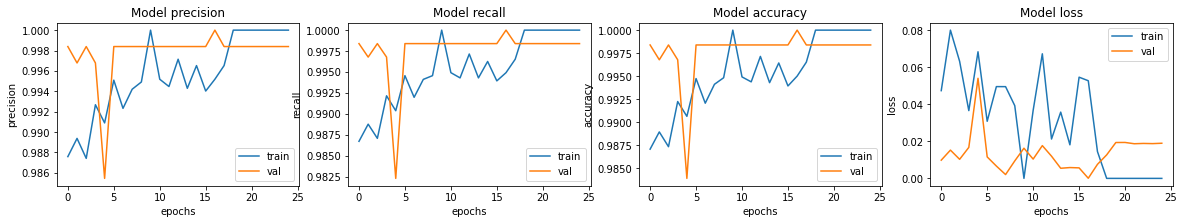

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 3))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall', 'accuracy', 'loss']):
    ax[i].plot(Info.history[met])
    ax[i].plot(Info.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [ ]:
predictions = model.predict(test_dataset)

In [ ]:
diseases_labels = []

for key, value in train_dataset.class_indices.items():
   diseases_labels.append(key)

In [ ]:
def evaluate(actual, predictions):
  pre = []
  for i in predictions:
    pre.append(np.argmax(i))

  accuracy = (pre == actual).sum() / actual.shape[0]
  print(f'Accuracy: {accuracy}')

  precision, recall, f1_score, _ = precision_recall_fscore_support(actual, pre, average='macro')
  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1_score: {f1_score}')

  fig, ax = plt.subplots(figsize=(20,20))
  conf_mat = confusion_matrix(actual, pre)
  sns.heatmap(conf_mat, annot=True, fmt='.0f', cmap="YlGnBu", xticklabels=diseases_labels, yticklabels=diseases_labels).set_title('Confusion Matrix Heat map')
  plt.show()

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1_score: 1.0


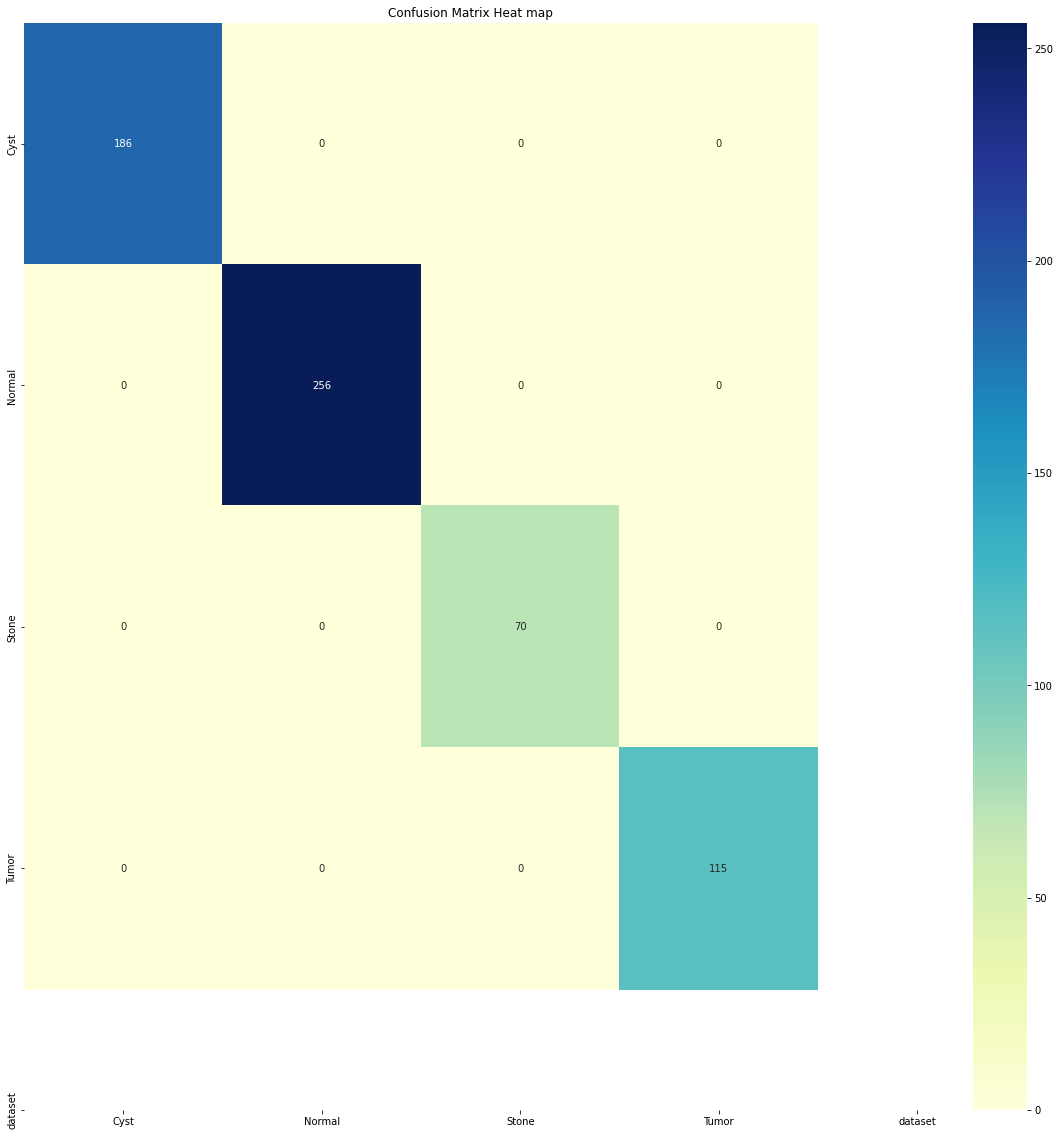

In [ ]:
evaluate(test_dataset.classes,predictions)

In [ ]:
model.evaluate(test_dataset)

7/7 [==============================] - 4s 624ms/step - loss: 1.9013e-10 - accuracy: 1.0000 - precision: 1.0000 - recall: 1.0000


[1.901264562453875e-10, 1.0, 1.0, 1.0]